# Midterm Project Analysis: Missile Attacks on Ukraine

This notebook contains the analysis of Russian missile and drone strikes against Ukrainian infrastructure.

## Environment Setup

In [1]:
%pip install pandas numpy plotly matplotlib seaborn scipy ipykernel


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required packages
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print('All packages imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

All packages imported successfully!
Pandas version: 3.0.1
NumPy version: 2.4.2


## Load Dataset

In [3]:
# Load the datasets
attacks_df = pd.read_csv('data/missile_attacks_daily.csv')
weapons_df = pd.read_csv('data/missiles_and_uavs.csv')

print(f'Missile Attacks Daily - Shape: {attacks_df.shape}')
print(f'Missiles and UAVs - Shape: {weapons_df.shape}')
print(f'\nFirst 10 rows of missile_attacks_daily.csv:')
attacks_df.head(10)

Missile Attacks Daily - Shape: (3412, 22)
Missiles and UAVs - Shape: (64, 12)

First 10 rows of missile_attacks_daily.csv:


,time_start,time_end,model,launch_place,target,target_main,launched,destroyed,not_reach_goal,still_attacking,...,num_hit_location,num_fall_fragment_location,carrier,turbojet,turbojet_destroyed,affected region,destroyed_details,launched_details,launch_place_details,source
0,2026-02-15 18:00,2026-02-16 09:00,X-31P,Zaporizhzhia oblast,Ukraine,NaN,1.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid02FADHWssAwVCGqvfhSJy6p33grx...
1,2026-02-15 18:00,2026-02-16 09:00,Shahed-136/131,Primorsko-Akhtarsk and Kursk oblast and Bryans...,Ukraine,NaN,62.0,52.0,0.0,1.0,...,8.0,2.0,NaN,NaN,NaN,NaN,"{'south': 1, 'east': NaN, 'north': NaN}",NaN,NaN,kpszsu/posts/pfbid02FADHWssAwVCGqvfhSJy6p33grx...
2,2026-02-15 18:00,2026-02-16 09:00,Iskander-M,Bryansk oblast,Ukraine,NaN,1.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid02FADHWssAwVCGqvfhSJy6p33grx...
3,2026-02-15 18:00,2026-02-16 09:00,3M22 Zircon,Crimea,Ukraine,NaN,4.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid02FADHWssAwVCGqvfhSJy6p33grx...
4,2026-02-14 18:30,2026-02-15 08:00,Shahed-136/131,"Primorsko-Akhtarsk and Chauda, Crimea and Brya...",Ukraine,NaN,83.0,55.0,0.0,3.0,...,12.0,3.0,NaN,NaN,NaN,NaN,"{'south': 22, 'east': NaN, 'north': NaN}",NaN,NaN,kpszsu/posts/pfbid0GzUWTJ83g643MFnrtmZdGxn6tVf...
5,2026-02-15,2026-02-15,Молнія,NaN,south,NaN,3.0,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PvKPivden/posts/pfbid02AfkGxkTncqCgzPjcwqNkZRY...
6,2026-02-15,2026-02-15,Reconnaissance UAV,NaN,south,NaN,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PvKPivden/posts/pfbid02AfkGxkTncqCgzPjcwqNkZRY...
7,2026-02-13 18:30,2026-02-14 08:30,Shahed-136/131,Primorsko-Akhtarsk and Kursk oblast and Bryans...,Ukraine,NaN,112.0,91.0,0.0,3.0,...,11.0,2.0,NaN,NaN,NaN,NaN,"{'south': 6, 'west': 11, 'east': NaN, 'north':...",NaN,NaN,kpszsu/posts/pfbid02c1AgHwW6Jw4opmxgGEA1bP8WHy...
8,2026-02-13 18:30,2026-02-14 08:30,Iskander-M,Kursk oblast,Ukraine,NaN,1.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid02c1AgHwW6Jw4opmxgGEA1bP8WHy...
9,2026-02-14,2026-02-14,Молнія,NaN,south,NaN,20.0,20.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PvKPivden/posts/pfbid02z6RNnsh7nLkD38sPEkKnoAc...


In [4]:
print(f'\nFirst 10 rows of missiles_and_uavs.csv:')
weapons_df.head(10)


First 10 rows of missiles_and_uavs.csv:


,model,category,national_origin,type,launch_platform,name,name_NATO,in_sevice,designer,manufacturer,guidance_system,unit_cost
0,Eleron,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,ENICS,NaN,NaN
1,Forpost,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,Ural Works of Civil Aviation,NaN,NaN
2,Granat-4,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,Ижмаш – беспилотные системы,NaN,NaN
3,Kub,UAV,russia,loitering munition,NaN,NaN,NaN,NaN,NaN,ZALA Aero Group,NaN,NaN
4,Lancet,UAV,russia,loitering munition,NaN,NaN,NaN,NaN,NaN,ZALA Aero Group,NaN,NaN
5,Merlin-VR,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Mohajer-6,UAV,iran,multirole ISTAR,NaN,NaN,NaN,NaN,NaN,Qods Aviation Industry Company,NaN,NaN
7,Orion,UAV,russia,reconnaissance and armed,NaN,NaN,NaN,NaN,NaN,Kronstadt Group,NaN,NaN
8,Orlan-10,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,Special Technology Center,NaN,NaN
9,Orlan-10 and Orlan-30 and ZALA and Supercam,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Exploratory Data Analysis

In [5]:
# Dataset overview
print('Missile Attacks Daily Dataset Information:')
print('='*50)
print(attacks_df.info())
print('\nBasic Statistics:')
print(attacks_df.describe())

Missile Attacks Daily Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 3412 entries, 0 to 3411
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   time_start                  3412 non-null   str    
 1   time_end                    3412 non-null   str    
 2   model                       3412 non-null   str    
 3   launch_place                1758 non-null   str    
 4   target                      3382 non-null   str    
 5   target_main                 52 non-null     str    
 6   launched                    3409 non-null   float64
 7   destroyed                   3406 non-null   float64
 8   not_reach_goal              575 non-null    float64
 9   still_attacking             96 non-null     float64
 10  border_crossing             3412 non-null   str    
 11  is_shahed                   161 non-null    float64
 12  num_hit_location            270 non-null    float64
 13  n

In [6]:
# Weapons dataset overview
print('Missiles and UAVs Dataset Information:')
print('='*50)
print(weapons_df.info())
print('\nBasic Statistics:')
print(weapons_df.describe())

# Missing values analysis
print('\n\nMissing Values - Missile Attacks Daily:')
print(attacks_df.isnull().sum())
print('\nMissing Values - Missiles and UAVs:')
print(weapons_df.isnull().sum())

Missiles and UAVs Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            64 non-null     str    
 1   category         64 non-null     str    
 2   national_origin  61 non-null     str    
 3   type             36 non-null     str    
 4   launch_platform  17 non-null     str    
 5   name             20 non-null     str    
 6   name_NATO        15 non-null     str    
 7   in_sevice        9 non-null      float64
 8   designer         4 non-null      str    
 9   manufacturer     23 non-null     str    
 10  guidance_system  2 non-null      str    
 11  unit_cost        1 non-null      str    
dtypes: float64(1), str(11)
memory usage: 6.1 KB
None

Basic Statistics:
         in_sevice
count     9.000000
mean   2008.222222
std      17.746674
min    1978.000000
25%    2006.000000
50%    2017.000000
75%    2021.000000


## Binomial Logistic Regression (GLM): Likelihood of Interception

In this section we fit a **Binomial Logistic Regression** (a Generalized Linear Model with a logit link and binomial family) to estimate the probability that a given missile or UAV is **intercepted (shot down)** by Ukrainian air defenses.

### Approach

| Step | Description |
|------|-------------|
| **1. Data Preparation** | Merge `missile_attacks_daily` with `missiles_and_uavs` on the `model` column to enrich each attack record with weapon metadata (category, type, guidance system, etc.). |
| **2. Timestamp Filtering** | Retain only rows whose `time_start` includes an explicit HH:MM timestamp; rows with date-only values are excluded because we cannot determine day-vs-night. |
| **3. Sunrise / Sunset Retrieval** | For every unique attack date we query the free **Sunrise-Sunset API** (`https://api.sunrise-sunset.org`) using Kyiv coordinates (50.45 °N, 30.52 °E) to obtain civil sunrise and sunset times. |
| **4. Day / Night Classification** | Each attack is labelled **"day"** if its `time_start` falls between sunrise and sunset, or **"night"** otherwise. |
| **5. Feature Engineering** | Construct the design matrix with categorical predictors (`model`, `category`, `type`, day/night indicator) and the response as the number of `destroyed` out of `launched` (binomial trials). |
| **6. Model Fitting** | Fit the GLM using `statsmodels` with a logit link. Evaluate coefficients, p-values, and confidence intervals to identify which features significantly predict interception probability. |
| **7. Model Evaluation** | Assess goodness-of-fit via deviance, AIC, and a confusion-matrix on predicted vs. observed interception rates. |

> **Interpretation:** A positive coefficient means the feature *increases* the log-odds of interception; a negative coefficient means it *decreases* those odds. The day/night indicator tells us whether attacks launched during daylight are more or less likely to be intercepted than nighttime attacks.

In [7]:
%pip install statsmodels requests scikit-learn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import requests
from datetime import datetime, timezone
import time as _time
import warnings
import sklearn
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------
# Step 1 – Merge datasets on 'model'
# -------------------------------------------------------------------
merged_df = attacks_df.merge(weapons_df, on='model', how='left')
print(f'Merged dataset shape: {merged_df.shape}')
print(f'Rows with weapon metadata: {merged_df["category"].notna().sum()} / {len(merged_df)}')

# -------------------------------------------------------------------
# Step 2 – Filter to rows with explicit timestamps (contain ":")
# -------------------------------------------------------------------
has_time_start = merged_df['time_start'].astype(str).str.contains(r'\d{2}:\d{2}', na=False)
has_time_end   = merged_df['time_end'].astype(str).str.contains(r'\d{2}:\d{2}', na=False)
timed_df = merged_df[has_time_start & has_time_end].copy()
print(f'\nRows with valid start AND end timestamps: {len(timed_df)} / {len(merged_df)}')

# Parse datetime columns
timed_df['time_start_dt'] = pd.to_datetime(timed_df['time_start'], errors='coerce')
timed_df['time_end_dt']   = pd.to_datetime(timed_df['time_end'],   errors='coerce')
timed_df = timed_df.dropna(subset=['time_start_dt', 'time_end_dt'])

# Extract the date of the attack start for sunrise/sunset lookup
timed_df['attack_date'] = timed_df['time_start_dt'].dt.date
print(f'Unique attack dates: {timed_df["attack_date"].nunique()}')
timed_df.head()

Merged dataset shape: (3412, 33)
Rows with weapon metadata: 3403 / 3412

Rows with valid start AND end timestamps: 1330 / 3412
Unique attack dates: 677


,time_start,time_end,model,launch_place,target,target_main,launched,destroyed,not_reach_goal,still_attacking,...,name,name_NATO,in_sevice,designer,manufacturer,guidance_system,unit_cost,time_start_dt,time_end_dt,attack_date
0,2026-02-15 18:00,2026-02-16 09:00,X-31P,Zaporizhzhia oblast,Ukraine,NaN,1.0,0.0,NaN,NaN,...,Kh-31P,AS-17 'Krypton',NaN,NaN,NaN,NaN,NaN,2026-02-15 18:00:00,2026-02-16 09:00:00,2026-02-15
1,2026-02-15 18:00,2026-02-16 09:00,Shahed-136/131,Primorsko-Akhtarsk and Kursk oblast and Bryans...,Ukraine,NaN,62.0,52.0,0.0,1.0,...,NaN,NaN,NaN,NaN,Shahed Aviation Industries,NaN,NaN,2026-02-15 18:00:00,2026-02-16 09:00:00,2026-02-15
2,2026-02-15 18:00,2026-02-16 09:00,Iskander-M,Bryansk oblast,Ukraine,NaN,1.0,0.0,NaN,NaN,...,Iskander-M,NaN,2006.0,NaN,Votkinsk Plant State Production Association,"Inertial, optical DSMAC",NaN,2026-02-15 18:00:00,2026-02-16 09:00:00,2026-02-15
3,2026-02-15 18:00,2026-02-16 09:00,3M22 Zircon,Crimea,Ukraine,NaN,4.0,2.0,NaN,NaN,...,Zircon,SS-N-33,2021.0,NaN,NPO Mashinostroyeniya,NaN,~10 million USD,2026-02-15 18:00:00,2026-02-16 09:00:00,2026-02-15
4,2026-02-14 18:30,2026-02-15 08:00,Shahed-136/131,"Primorsko-Akhtarsk and Chauda, Crimea and Brya...",Ukraine,NaN,83.0,55.0,0.0,3.0,...,NaN,NaN,NaN,NaN,Shahed Aviation Industries,NaN,NaN,2026-02-14 18:30:00,2026-02-15 08:00:00,2026-02-14


In [9]:
# -------------------------------------------------------------------
# Step 3 – Retrieve sunrise / sunset times via API (with JSON cache)
# -------------------------------------------------------------------
# Using https://api.sunrise-sunset.org (free, no key required)
# Kyiv coordinates: 50.4501 N, 30.5234 E
# Results are cached in data/sun_cache.json to avoid repeated API calls.

import json
from pathlib import Path

KYIV_LAT, KYIV_LNG = 50.4501, 30.5234
SUN_CACHE_PATH = Path('data/sun_cache.json')

unique_dates = sorted(timed_df['attack_date'].unique())

# ------ load existing cache from disk (if available) ------
if SUN_CACHE_PATH.exists():
    with open(SUN_CACHE_PATH, 'r') as f:
        raw_cache = json.load(f)
    # Convert stored strings back to pandas Timestamps
    sun_cache = {
        pd.Timestamp(k).date(): {
            'sunrise': pd.to_datetime(v['sunrise']),
            'sunset':  pd.to_datetime(v['sunset']),
        }
        for k, v in raw_cache.items()
    }
    print(f'Loaded {len(sun_cache)} cached sunrise/sunset entries from {SUN_CACHE_PATH}')
else:
    sun_cache = {}
    print('No cache file found – will fetch from API.')

# ------ fetch only the dates not already cached ------
dates_to_fetch = [d for d in unique_dates if d not in sun_cache]
print(f'Dates needed: {len(unique_dates)} | Already cached: {len(unique_dates) - len(dates_to_fetch)} | To fetch: {len(dates_to_fetch)}')

for i, d in enumerate(dates_to_fetch):
    date_str = str(d)
    url = (
        f'https://api.sunrise-sunset.org/json'
        f'?lat={KYIV_LAT}&lng={KYIV_LNG}'
        f'&date={date_str}&formatted=0'
    )
    try:
        resp = requests.get(url, timeout=10)
        data = resp.json()
        if data['status'] == 'OK':
            sunrise_utc = pd.to_datetime(data['results']['sunrise'])
            sunset_utc  = pd.to_datetime(data['results']['sunset'])
            # Convert from UTC to Kyiv local time (UTC+2 in winter / UTC+3 in summer)
            # Ukraine observes EET (UTC+2) / EEST (UTC+3).  A simple offset approach:
            # Since the data timestamps appear to already be in local (Kyiv) time,
            # we convert sunrise/sunset to UTC+2 for comparison.
            kyiv_offset = pd.Timedelta(hours=2)
            sun_cache[d] = {
                'sunrise': sunrise_utc + kyiv_offset,
                'sunset':  sunset_utc  + kyiv_offset,
            }
        else:
            print(f'  Warning: API returned status={data["status"]} for {date_str}')
    except Exception as e:
        print(f'  Error fetching {date_str}: {e}')
    # Respect API rate limits
    if (i + 1) % 5 == 0:
        _time.sleep(1)

# ------ persist cache to disk ------
if dates_to_fetch:
    serializable = {
        str(k): {
            'sunrise': v['sunrise'].isoformat(),
            'sunset':  v['sunset'].isoformat(),
        }
        for k, v in sun_cache.items()
    }
    with open(SUN_CACHE_PATH, 'w') as f:
        json.dump(serializable, f, indent=2)
    print(f'Cache updated – wrote {len(serializable)} entries to {SUN_CACHE_PATH}')

print(f'Successfully have sun data for {len(sun_cache)} / {len(unique_dates)} dates')

# Show a few examples
sample_dates = list(sun_cache.items())[:5]
for d, times in sample_dates:
    print(f'  {d}  sunrise={times["sunrise"].strftime("%H:%M")}  sunset={times["sunset"].strftime("%H:%M")}')

Loaded 677 cached sunrise/sunset entries from data/sun_cache.json
Dates needed: 677 | Already cached: 677 | To fetch: 0
Successfully have sun data for 677 / 677 dates
  2022-09-29  sunrise=05:53  sunset=17:43
  2022-10-01  sunrise=05:56  sunset=17:38
  2022-10-02  sunrise=05:58  sunset=17:36
  2022-10-05  sunrise=06:02  sunset=17:29
  2022-10-06  sunrise=06:04  sunset=17:27


In [10]:
# -------------------------------------------------------------------
# Step 4 – Classify each attack as "day" or "night"
# -------------------------------------------------------------------

def classify_day_night(row):
    """Return 1 for daytime (between sunrise and sunset) or 0 for nighttime."""
    d = row['attack_date']
    if d not in sun_cache:
        return np.nan
    sunrise = sun_cache[d]['sunrise']
    sunset  = sun_cache[d]['sunset']
    attack_time = row['time_start_dt']
    # Compare only the time component on the same calendar day
    attack_hour_min = attack_time.hour * 60 + attack_time.minute
    sunrise_hm = sunrise.hour * 60 + sunrise.minute
    sunset_hm  = sunset.hour * 60 + sunset.minute
    return 1 if sunrise_hm <= attack_hour_min <= sunset_hm else 0

timed_df['is_daytime'] = timed_df.apply(classify_day_night, axis=1)
timed_df = timed_df.dropna(subset=['is_daytime'])
timed_df['is_daytime'] = timed_df['is_daytime'].astype(int)

print('Day / Night distribution:')
print(timed_df['is_daytime'].value_counts().rename({1: 'Day', 0: 'Night'}))
print(f'\nTotal rows for modelling: {len(timed_df)}')

Day / Night distribution:
is_daytime
Night    1051
Day       278
Name: count, dtype: int64

Total rows for modelling: 1329


In [11]:
# -------------------------------------------------------------------
# Step 5 – Feature engineering for the GLM
# -------------------------------------------------------------------

# Clean up launched / destroyed columns
glm_df = timed_df.copy()
glm_df['launched']  = pd.to_numeric(glm_df['launched'],  errors='coerce')
glm_df['destroyed'] = pd.to_numeric(glm_df['destroyed'], errors='coerce')
glm_df = glm_df.dropna(subset=['launched', 'destroyed'])
glm_df = glm_df[glm_df['launched'] > 0]  # must have at least 1 launch

# Cap destroyed at launched (data quality)
glm_df['destroyed'] = glm_df['destroyed'].clip(upper=glm_df['launched'])

# Number NOT destroyed (failures from the interception perspective)
glm_df['not_destroyed'] = glm_df['launched'] - glm_df['destroyed']

# Fill missing categorical features
glm_df['category'] = glm_df['category'].fillna('Unknown')
glm_df['type']     = glm_df['type'].fillna('Unknown')

# Collapse rare model categories (<10 occurrences) into "Other"
model_counts = glm_df['model'].value_counts()
rare_models = model_counts[model_counts < 10].index
glm_df['model_group'] = glm_df['model'].where(~glm_df['model'].isin(rare_models), 'Other')

# Collapse rare categories the same way
cat_counts = glm_df['category'].value_counts()
rare_cats = cat_counts[cat_counts < 5].index
glm_df['category_group'] = glm_df['category'].where(~glm_df['category'].isin(rare_cats), 'Other')

# Extract hour of attack for additional granularity
glm_df['attack_hour'] = glm_df['time_start_dt'].dt.hour

# Interception rate by key groupings
print('Interception rate by day/night:')
day_night_stats = glm_df.groupby('is_daytime').agg(
    total_launched=('launched', 'sum'),
    total_destroyed=('destroyed', 'sum')
)
day_night_stats['intercept_rate'] = day_night_stats['total_destroyed'] / day_night_stats['total_launched']
day_night_stats.index = day_night_stats.index.map({0: 'Night', 1: 'Day'})
print(day_night_stats)

print('\nInterception rate by category:')
cat_stats = glm_df.groupby('category_group').agg(
    total_launched=('launched', 'sum'),
    total_destroyed=('destroyed', 'sum')
)
cat_stats['intercept_rate'] = cat_stats['total_destroyed'] / cat_stats['total_launched']
print(cat_stats.sort_values('intercept_rate', ascending=False))

print(f'\nFinal GLM dataset: {len(glm_df)} rows')
glm_df[['model', 'category_group', 'is_daytime', 'launched', 'destroyed', 'not_destroyed', 'attack_hour']].head(10)

Interception rate by day/night:
            total_launched  total_destroyed  intercept_rate
is_daytime                                                 
Night              60048.0          41896.0        0.697708
Day                13510.0           8432.0        0.624130

Interception rate by category:
                              total_launched  total_destroyed  intercept_rate
category_group                                                               
cruise missile                        3224.0           2483.0        0.770161
UAV                                  69122.0          47538.0        0.687741
Other                                   87.0             46.0        0.528736
surface-to-air and ballistic           158.0             65.0        0.411392
ballistic missile                      749.0            196.0        0.261682
surface-to-air missile                 218.0              0.0        0.000000

Final GLM dataset: 1325 rows


,model,category_group,is_daytime,launched,destroyed,not_destroyed,attack_hour
0,X-31P,cruise missile,0,1.0,0.0,1.0,18
1,Shahed-136/131,UAV,0,62.0,52.0,10.0,18
2,Iskander-M,ballistic missile,0,1.0,0.0,1.0,18
3,3M22 Zircon,cruise missile,0,4.0,2.0,2.0,18
4,Shahed-136/131,UAV,0,83.0,55.0,28.0,18
7,Shahed-136/131,UAV,0,112.0,91.0,21.0,18
8,Iskander-M,ballistic missile,0,1.0,0.0,1.0,18
10,Shahed-136/131,UAV,0,154.0,111.0,43.0,18
11,Iskander-M,ballistic missile,0,1.0,0.0,1.0,18
16,X-59/X-69,cruise missile,0,1.0,1.0,0.0,18


In [12]:
# -------------------------------------------------------------------
# Step 6 – Fit Binomial Logistic Regression (GLM)
# -------------------------------------------------------------------

# Encode categoricals for the formula interface
# We use C() notation so statsmodels treats them as categorical

# Model 1: Day/Night only
print('='*70)
print('MODEL 1: Day/Night indicator only')
print('='*70)
model1 = smf.glm(
    'destroyed + not_destroyed ~ is_daytime',
    data=glm_df,
    family=sm.families.Binomial()
).fit()
print(model1.summary())

print(f'\nAIC: {model1.aic:.2f}')
print(f'Deviance: {model1.deviance:.2f}')

MODEL 1: Day/Night indicator only
                       Generalized Linear Model Regression Results                        
Dep. Variable:     ['destroyed', 'not_destroyed']   No. Observations:                 1325
Model:                                        GLM   Df Residuals:                     1323
Model Family:                            Binomial   Df Model:                            1
Link Function:                              Logit   Scale:                          1.0000
Method:                                      IRLS   Log-Likelihood:                -9279.5
Date:                            Wed, 25 Feb 2026   Deviance:                       15655.
Time:                                    22:06:58   Pearson chi2:                 1.42e+04
No. Iterations:                                 4   Pseudo R-squ. (CS):             0.1843
Covariance Type:                        nonrobust                                         
                 coef    std err          z      P>|z|  

In [13]:
# Model 2: Category + Day/Night
print('='*70)
print('MODEL 2: Category + Day/Night')
print('='*70)
model2 = smf.glm(
    'destroyed + not_destroyed ~ C(category_group) + is_daytime',
    data=glm_df,
    family=sm.families.Binomial()
).fit()
print(model2.summary())

print(f'\nAIC: {model2.aic:.2f}')
print(f'Deviance: {model2.deviance:.2f}')

MODEL 2: Category + Day/Night
                       Generalized Linear Model Regression Results                        
Dep. Variable:     ['destroyed', 'not_destroyed']   No. Observations:                 1325
Model:                                        GLM   Df Residuals:                     1318
Model Family:                            Binomial   Df Model:                            6
Link Function:                              Logit   Scale:                          1.0000
Method:                                      IRLS   Log-Likelihood:                -8649.8
Date:                            Wed, 25 Feb 2026   Deviance:                       14396.
Time:                                    22:06:58   Pearson chi2:                 1.33e+04
No. Iterations:                                24   Pseudo R-squ. (CS):             0.6847
Covariance Type:                        nonrobust                                         
                                                        coef

In [14]:
# Model 3: Full model – Model group + Category + Day/Night
print('='*70)
print('MODEL 3: Full model – Model group + Category + Day/Night')
print('='*70)
model3 = smf.glm(
    'destroyed + not_destroyed ~ C(model_group) + C(category_group) + is_daytime',
    data=glm_df,
    family=sm.families.Binomial()
).fit()
print(model3.summary())

print(f'\nAIC: {model3.aic:.2f}')
print(f'Deviance: {model3.deviance:.2f}')

MODEL 3: Full model – Model group + Category + Day/Night
                       Generalized Linear Model Regression Results                        
Dep. Variable:     ['destroyed', 'not_destroyed']   No. Observations:                 1325
Model:                                        GLM   Df Residuals:                     1301
Model Family:                            Binomial   Df Model:                           23
Link Function:                              Logit   Scale:                          1.0000
Method:                                      IRLS   Log-Likelihood:                -8431.1
Date:                            Wed, 25 Feb 2026   Deviance:                       13958.
Time:                                    22:06:58   Pearson chi2:                 1.28e+04
No. Iterations:                                24   Pseudo R-squ. (CS):             0.7733
Covariance Type:                        nonrobust                                         
                                 

In [15]:
# -------------------------------------------------------------------
# Step 7 – Model comparison & evaluation
# -------------------------------------------------------------------

# AIC comparison
print('Model Comparison (lower AIC is better):')
print(f'  Model 1 (Day/Night only):           AIC = {model1.aic:>10.2f}')
print(f'  Model 2 (Category + Day/Night):      AIC = {model2.aic:>10.2f}')
print(f'  Model 3 (Model + Category + D/N):    AIC = {model3.aic:>10.2f}')

best_model = min([(model1, 'Model 1'), (model2, 'Model 2'), (model3, 'Model 3')],
                 key=lambda x: x[0].aic)
print(f'\n  ➜ Best model by AIC: {best_model[1]}')

# Odds ratios for the best model's coefficients
print('\n' + '='*70)
print(f'Odds Ratios – {best_model[1]}')
print('='*70)
odds = np.exp(best_model[0].params)
ci = np.exp(best_model[0].conf_int())
ci.columns = ['OR_lower_95', 'OR_upper_95']
odds_df = pd.DataFrame({'OddsRatio': odds}).join(ci)
odds_df['p_value'] = best_model[0].pvalues
print(odds_df.sort_values('p_value'))

Model Comparison (lower AIC is better):
  Model 1 (Day/Night only):           AIC =   18563.04
  Model 2 (Category + Day/Night):      AIC =   17313.59
  Model 3 (Model + Category + D/N):    AIC =   16910.28

  ➜ Best model by AIC: Model 3

Odds Ratios – Model 3
                                                      OddsRatio  OR_lower_95  \
is_daytime                                         7.095193e-01     0.682120   
C(category_group)[T.cruise missile]                3.114745e+00     1.994254   
C(category_group)[T.UAV]                           5.842597e+00     2.361693   
C(category_group)[T.surface-to-air and ballistic]  5.940878e-01     0.350557   
C(category_group)[T.ballistic missile]             5.100015e-01     0.170365   
C(category_group)[T.surface-to-air missile]        6.650784e-12     0.000000   
C(model_group)[T.Orlan-10]                         2.191224e+10     0.000000   
C(model_group)[T.Supercam]                         2.239629e+10     0.000000   
C(model_group)[T.X

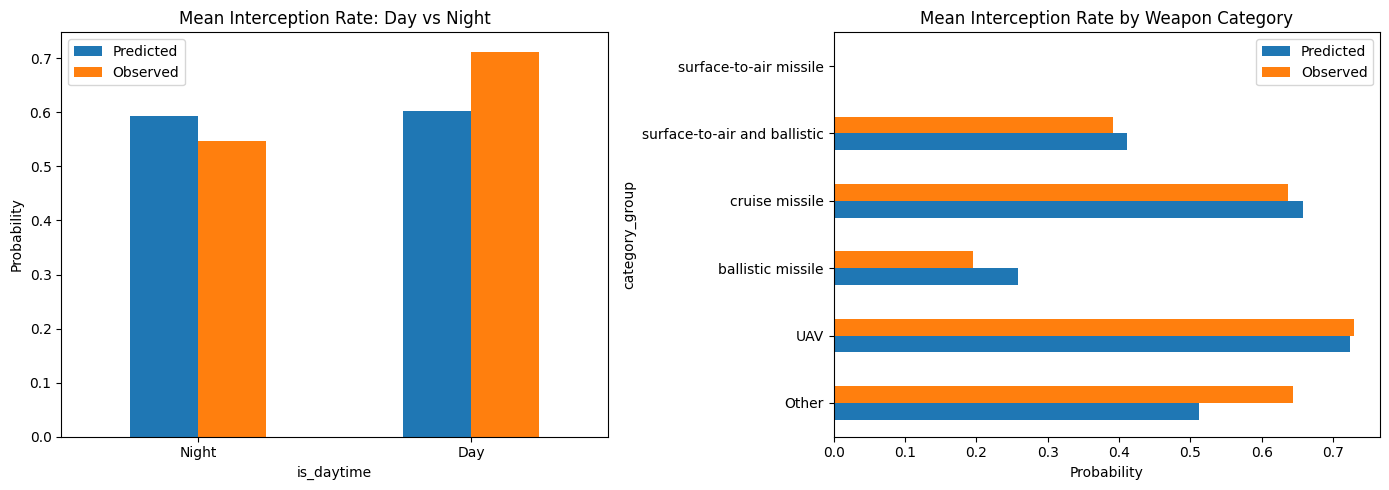

In [16]:
# -------------------------------------------------------------------
# Predicted interception probability vs observed – visual check
# -------------------------------------------------------------------
glm_df['predicted_prob'] = best_model[0].predict(glm_df)
glm_df['observed_rate']  = glm_df['destroyed'] / glm_df['launched']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Panel A: by day/night --
day_night_pred = glm_df.groupby('is_daytime').agg(
    mean_predicted=('predicted_prob', 'mean'),
    mean_observed=('observed_rate', 'mean')
)
day_night_pred.index = day_night_pred.index.map({0: 'Night', 1: 'Day'})
day_night_pred.plot.bar(ax=axes[0], rot=0, color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Mean Interception Rate: Day vs Night')
axes[0].set_ylabel('Probability')
axes[0].legend(['Predicted', 'Observed'])

# -- Panel B: by weapon category --
cat_pred = glm_df.groupby('category_group').agg(
    mean_predicted=('predicted_prob', 'mean'),
    mean_observed=('observed_rate', 'mean')
)
cat_pred.plot.barh(ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Mean Interception Rate by Weapon Category')
axes[1].set_xlabel('Probability')
axes[1].legend(['Predicted', 'Observed'])

plt.tight_layout()
plt.show()

Confusion Matrix (Majority Intercepted: ≥50%):
[[279 169]
 [ 63 814]]

Classification Report:
                  precision    recall  f1-score   support

<50% intercepted       0.82      0.62      0.71       448
≥50% intercepted       0.83      0.93      0.88       877

        accuracy                           0.82      1325
       macro avg       0.82      0.78      0.79      1325
    weighted avg       0.82      0.82      0.82      1325



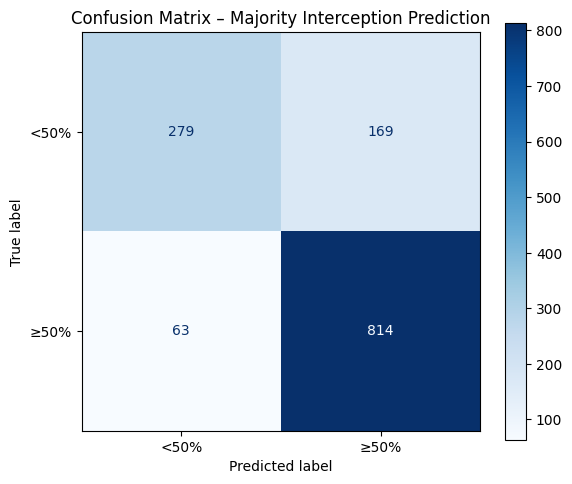

In [17]:
# -------------------------------------------------------------------
# Confusion matrix (binary: >50% intercepted vs ≤50%)
# -------------------------------------------------------------------
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

glm_df['pred_majority_intercepted'] = (glm_df['predicted_prob'] >= 0.5).astype(int)
glm_df['obs_majority_intercepted']  = (glm_df['observed_rate']  >= 0.5).astype(int)

cm = confusion_matrix(glm_df['obs_majority_intercepted'], glm_df['pred_majority_intercepted'])
print('Confusion Matrix (Majority Intercepted: ≥50%):')
print(cm)
print('\nClassification Report:')
print(classification_report(
    glm_df['obs_majority_intercepted'],
    glm_df['pred_majority_intercepted'],
    target_names=['<50% intercepted', '≥50% intercepted']
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['<50%', '≥50%']).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix – Majority Interception Prediction')
plt.tight_layout()
plt.show()

### GLM Results – Interpretation

**Key questions answered:**

1. **Can the weapon type predict interception probability?**  
   Compare AIC across models. If Model 3 (which includes `model_group` and `category`) has a substantially lower AIC than Model 1 (day/night only), then weapon type is informative.

2. **Are missiles/UAVs more likely to be shot down during the day or at night?**  
   Look at the `is_daytime` coefficient:
   - **Positive coefficient** → daytime attacks have *higher* interception odds.
   - **Negative coefficient** → nighttime attacks are *more* likely to be intercepted.
   
   The odds ratio quantifies the effect size (e.g., OR = 1.5 means 50 % higher odds during the day).

3. **Which features matter most?**  
   Features with p-values < 0.05 are statistically significant predictors. The odds-ratio table ranks them by significance.

> **Note:** The model uses a **binomial GLM** (logit link), treating each row as `destroyed` successes out of `launched` trials. This correctly accounts for varying volley sizes rather than naively binarising each row.